# Tokens

## 1. What is a Token & Why Do We Use Them?
Computers and neural networks cannot process raw human text directly; they operate strictly on mathematical vectors and matrices. A token is the atomic unit of text that an LLM reads, processes, and generates.

Raw Text:    "Understanding tokens in LLMs"
Tokens:      ["Under", "standing", "Ġtokens", "Ġin", "ĠLL", "Ms"]
Token IDs:   [14825, 4128, 16326, 287, 2107, 2486]

### Why not characters or whole words?
- Characters (Too granular): If models processed character-by-character (['c', 'a', 't']), sequence lengths would explode by $4\times\text{ to }5\times$. Since self-attention scales quadratically ($O(N^2)$) or linearly with large KV cache overhead, this would cripple memory and processing speed.
- Whole Words (Too rigid): A word-level vocabulary would need to contain millions of entries (every tense, typo, slang, and compound word like unhappiness, unhappy, unhappily). Any unseen word becomes an <UNK> (Unknown Token) error.
- Subwords (The sweet spot): Modern tokenizers use subword algorithms (like Byte-Pair Encoding or SentencePiece). Frequent words get single tokens (" the"), while rare or complex words are split into known pieces ("micro" + "service").

## Tokenization Algorithms Under the Hood
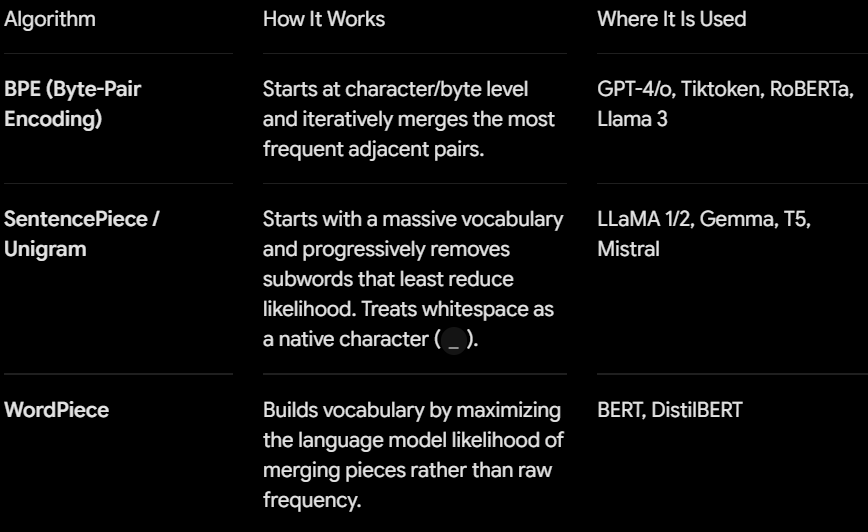

## The Lifecycle: From Text to Generation

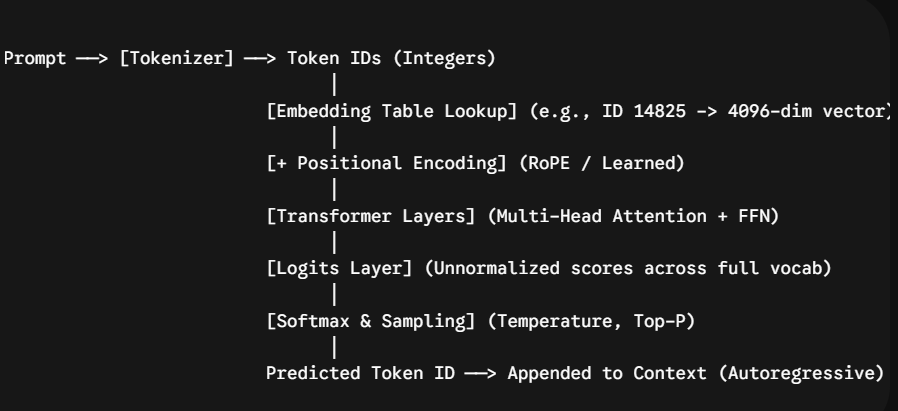

## What If We Directly Send Token IDs Instead of Raw Text?
A common architecture and interview question: Can we skip text transmission and send raw token integer arrays directly to the model?
- In API Endpoints (OpenAI, Anthropic, Gemini): You cannot pass raw token arrays directly over public REST endpoints. API gateways sanitize inputs, enforce moderation guards, handle chat templates (e.g., <|im_start|>system...), and enforce platform-level prompt caching.
- In Self-Hosted Systems (vLLM, TGI, TensorRT-LLM, PyTorch): Yes, you can and often should. Passing tokenized IDs directly to your inference server avoids duplicate tokenization on every HTTP worker thread, enables custom token-level logit bias, and lets you inject pre-computed embeddings.
- Tokenizer Mismatch Risk: Token IDs are completely arbitrary indexes in a specific vocabulary table. Passing tiktoken IDs to a Llama-3 model produces complete gibberish because ID 14825 maps to different words in different models.

## Token Economics & Cost Architecture
Total Cost = (Uncached Input × Rate_in) + (Cached Input × Rate_cached) + (Output × Rate_out) + (Reasoning × Rate_reasoning)
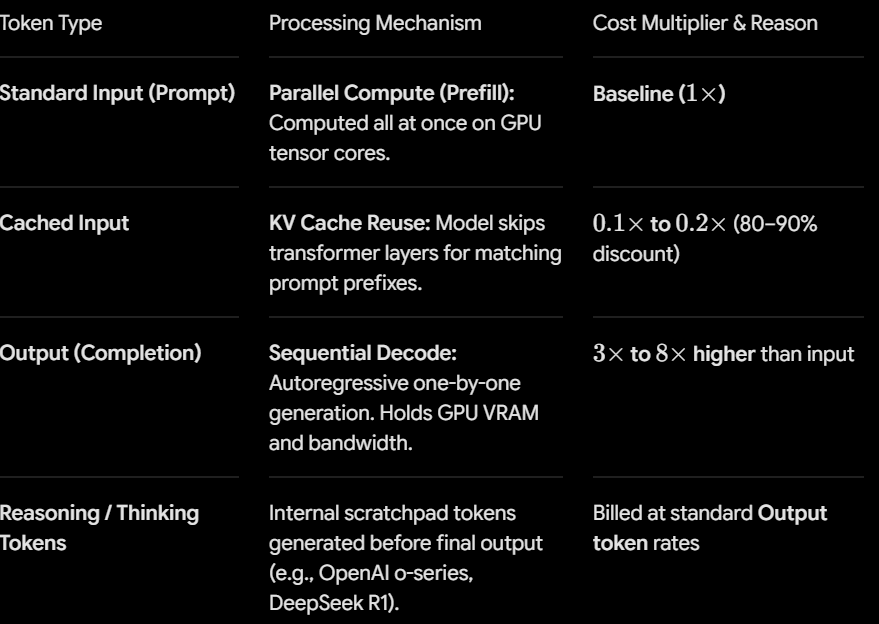

## Context Window & System Latency Metrics

- Context Window: The upper bound of tokens (input + output) a model can hold in GPU VRAM during an active inference session.
- TTFT (Time to First Token): Latency from request submission to the arrival of the first output token. Driven by input token length and prompt prefill speed.
- TPOT (Time Per Output Token): Inter-token latency during streaming. Driven by model parameter size, GPU memory bandwidth, and batch concurrency.
- The "Lost-in-the-Middle" Phenomenon: Despite context windows reaching 1M+ tokens, transformer self-attention mechanisms prioritize tokens at the beginning (primacy effect) and end (recency effect) of the prompt, occasionally missing data buried in the center.

## Production Optimization: Reducing Token Usage by 60–80%

INCOMING QUERY -> [QUERY CLASSIFIER]
                      -> SIMPLE -> SMALL MODEL
                      -> COMPLEX -> RE-RANKER ->
                                  STATIC CACHE PREFIX -> LLM

- Leverage Prompt Caching (Prefix Matching): Keep static content (system prompt, few-shot examples, tool schemas) at the top of the prompt. Dynamic user inputs must go at the very end to guarantee high cache-hit ratios.
- Deterministic Token-Aware Chunking (RAG): Never chunk documents by arbitrary character counts. Use model-native tokenizers (e.g., Hugging Face tokenizers) to chunk text along natural sentence boundaries without splitting token words in half.
- Cross-Encoder Re-ranking: In RAG pipelines, retrieve 20 candidate chunks via vector search, run them through a lightweight re-ranker (e.g., Cohere/BGE), and pass only the top 3 chunks into the LLM context.
- Structured Schema Minification: When enforcing structured outputs via Pydantic, strip verbose field descriptions from production schemas once the model has been evaluated, or use compact keys.
- Dynamic Model Routing: Route simple intent classification or entity extraction tasks to low-cost models (e.g., GPT-4o-mini, Gemini 2.5 Flash), reserving flagship reasoning models solely for multi-step reasoning.

## QUESTIONS
- Why does an LLM fail at spelling tasks like "How many 'r's in strawberry?"
 [ answer ] tokenizers chunk words into subwords (["str", "aw", "berry"]). The model processes tokens, not characters, so it never "sees" the individual letters unless explicitly prompted to spell character-by-character or assisted by a regex tool.
- What is the difference between BPE and SentencePiece?
[ answer ]  BPE requires pre-tokenization (splitting by spaces) before learning merges. SentencePiece treats the entire input as a raw byte/character stream where whitespace is just another symbol (_), making it language-agnostic and resilient for non-Latin scripts.
- Why is output generation more expensive than input processing?
[ answer ]  Input tokens are processed in parallel during the prefill phase, maximizing GPU tensor core utilization. Output tokens must be generated autoregressively one token at a time, creating memory bandwidth bottlenecks and keeping GPU compute state occupied longer.

In [37]:
import tiktoken

encoder = tiktoken.get_encoding("cl100k_base") 
text = "anand"
token_ids = encoder.encode(text)
print(f"Token IDs: {token_ids}")

for token_id in token_ids : 
    token_bytes = encoder.decode_single_token_bytes(token_id)
    print(f"{token_id} -> {token_bytes.decode('utf-8')}")

decoded_text = encoder.decode(token_ids)
print(f"Decoded: {decoded_text}")

Token IDs: [276, 438]
276 -> an
438 -> and
Decoded: anand
